# Exploratory Data Analysis (EDA) - Crime Pattern Analysis

This notebook performs Exploratory Data Analysis on the India crime incidents dataset. The analysis focuses on temporal patterns, spatial distribution, crime category distribution, trends over time, and correlation among numerical features.

The purpose of this notebook is to understand crime patterns and generate insights that can support feature selection and future machine learning-based crime prediction models.

In [13]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset

df = pd.read_csv("india_crime_incidents_master.csv")

# Convert TIMESTAMP column into datetime format
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"], errors="coerce")

# Display basic information
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (380145, 13)


,INCIDENT_ID,STATE/UT,DISTRICT,POLICE_STATION,CRIME_CATEGORY,TIMESTAMP,LATITUDE,LONGITUDE,POPULATION,LITERACY_RATE,SEX_RATIO,SC_ST_PERCENTAGE,URBAN_RATIO
0,FIR-2020-009313,DELHI,EAST,EAST P.S. 2,OTHER THEFT,2020-01-01 00:01:19,28.59832,77.21849,1903069,79.15,883.6,16.46,99.77
1,FIR-2020-186016,TELANGANA,CYBERABAD,CYBERABAD P.S. 6,THEFT,2020-01-01 00:03:22,18.22077,78.87612,1209997,74.04,943.0,25.20,31.20
2,FIR-2020-025124,DELHI,NORTH,NORTH P.S. 3,OTHER THEFT,2020-01-01 00:04:39,28.63297,77.21315,988614,76.75,869.4,18.66,98.50
3,FIR-2020-093645,DELHI,SOUTH-EAST,SOUTH-EAST P.S. 1,ROBBERY,2020-01-01 00:20:39,28.63132,77.13170,1903069,79.15,883.6,16.46,99.77
4,FIR-2020-204980,UTTAR PRADESH,KANPUR NAGAR,KANPUR NAGAR P.S. 4,OTHER IPC CRIMES,2020-01-01 00:21:10,26.44543,80.29166,5091212,70.79,862.5,17.91,65.24


In [ ]:
# Display dataset columns

print(df.columns)

Index(['INCIDENT_ID', 'STATE/UT', 'DISTRICT', 'POLICE_STATION',
       'CRIME_CATEGORY', 'TIMESTAMP', 'LATITUDE', 'LONGITUDE', 'POPULATION',
       'LITERACY_RATE', 'SEX_RATIO', 'SC_ST_PERCENTAGE', 'URBAN_RATIO'],
      dtype='str')


## 1. Temporal Analysis

Temporal analysis helps us understand how crime incidents vary across different time periods such as hours, weekdays/weekends, and months.


### 1.1 Crime Frequency by Hour

This analysis shows the distribution of crime incidents across different hours of the day.

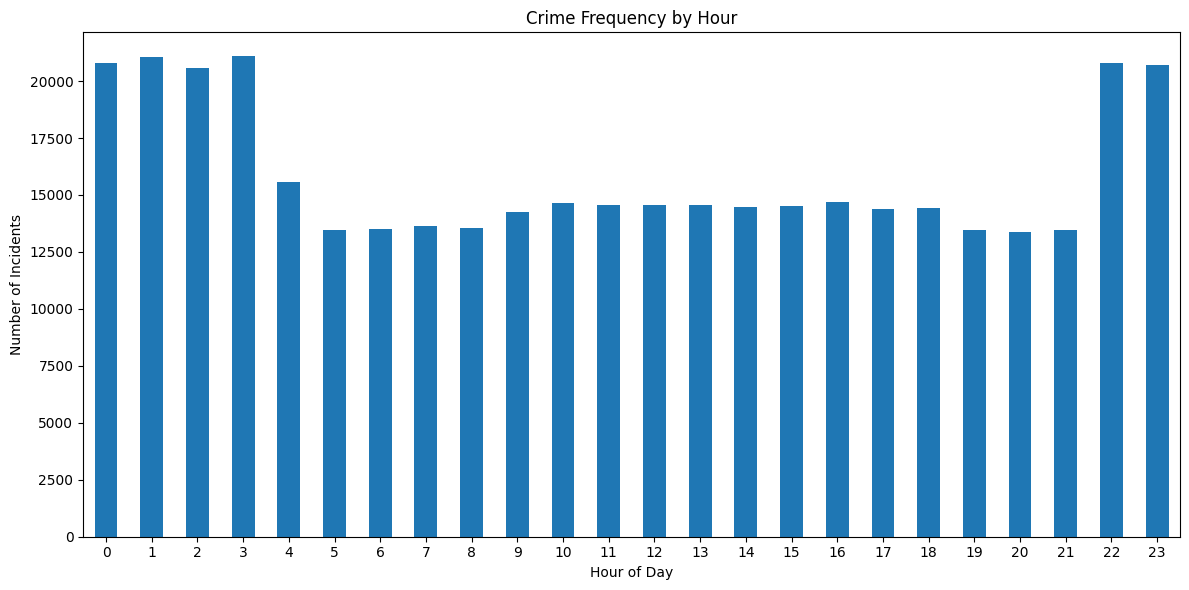

TIMESTAMP
0     20775
1     21060
2     20581
3     21086
4     15549
5     13463
6     13503
7     13640
8     13548
9     14269
10    14630
11    14553
12    14571
13    14575
14    14479
15    14528
16    14687
17    14403
18    14433
19    13471
20    13378
21    13470
22    20800
23    20693
Name: count, dtype: int64


In [ ]:
hourly_crime = df["TIMESTAMP"].dt.hour.value_counts().sort_index()

plt.figure(figsize=(12, 6))
hourly_crime.plot(kind="bar")

plt.title("Crime Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(hourly_crime)

### Observation

The graph shows that crime frequency varies across different hours of the day. Higher crime frequencies are observed during late-night and early-morning hours, especially around 12 AM, 1 AM, 3 AM, 10 PM, and 11 PM.

### Interpretation

This indicates that the time of occurrence may influence crime patterns. Late-night hours may be associated with increased crime reporting or higher opportunity for certain types of crimes.

### Conclusion

Hour of the day is an important temporal feature and can be useful for future predictive modeling.

### 1.2 Weekday vs Weekend Crime Distribution

This analysis compares crime incidents occurring on weekdays and weekends.

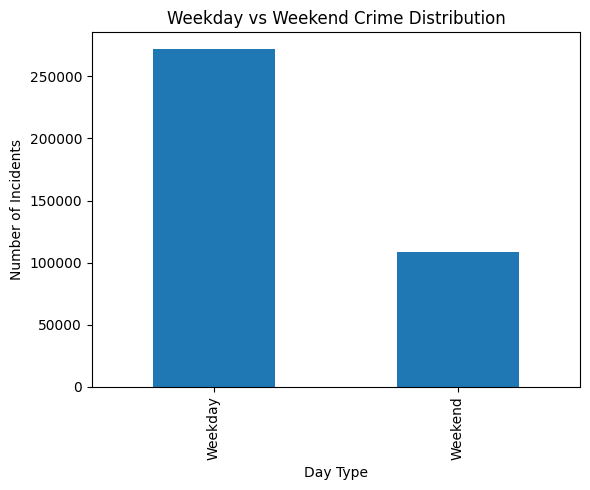

DAY_TYPE
Weekday    271792
Weekend    108353
Name: count, dtype: int64


In [ ]:
df["DAY_TYPE"] = df["TIMESTAMP"].dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

day_type_counts = df["DAY_TYPE"].value_counts()

plt.figure(figsize=(6, 5))
day_type_counts.plot(kind="bar")

plt.title("Weekday vs Weekend Crime Distribution")
plt.xlabel("Day Type")
plt.ylabel("Number of Incidents")

plt.tight_layout()
plt.show()

print(day_type_counts)

### Observation

Weekdays show a higher total number of crimes compared to weekends. However, weekdays also include five days, while weekends include only two days.

### Interpretation

When adjusted for the number of days, crime occurrence appears relatively consistent across weekdays and weekends.

### Conclusion

Day type alone may not be the strongest predictor of crime occurrence, but it can still provide useful contextual information.

### 1.3 Monthly Crime Trend

This analysis identifies seasonal or monthly variations in crime frequency.

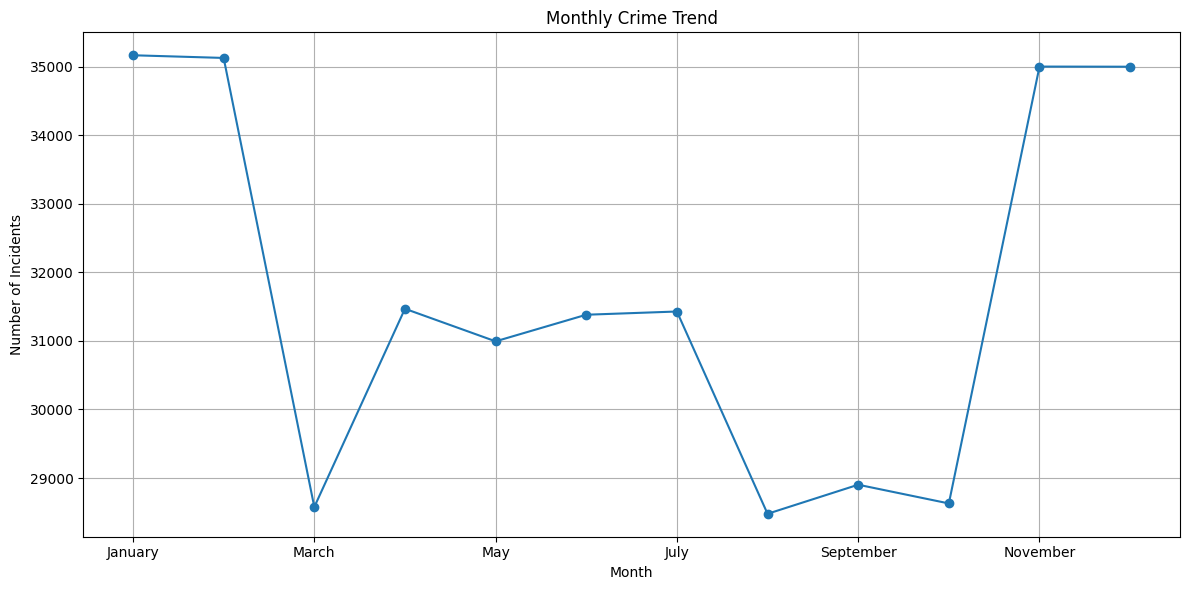

MONTH
January      35165
February     35126
March        28577
April        31468
May          30993
June         31381
July         31428
August       28478
September    28902
October      28629
November     35000
December     34998
Name: count, dtype: int64


In [ ]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

df["MONTH"] = pd.Categorical(
    df["TIMESTAMP"].dt.month_name(),
    categories=month_order,
    ordered=True
)

monthly_crime = df["MONTH"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
monthly_crime.plot(kind="line", marker="o")

plt.title("Monthly Crime Trend")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.grid(True)

plt.tight_layout()
plt.show()

print(monthly_crime)

### Observation

Higher crime frequencies are observed during January, February, November, and December. Lower crime frequencies are observed during months such as March, August, September, and October.

### Interpretation

The monthly trend suggests the presence of seasonal variation in crime occurrence. However, the variation is moderate rather than extremely sharp.

### Conclusion

Month-based features may improve crime forecasting and trend analysis.

## 2. Spatial Analysis

Spatial analysis helps identify locations and regions where crime incidents are concentrated.

### 2.1 Areas with Highest Crime Concentration

This analysis identifies the top districts with the highest number of crime incidents.

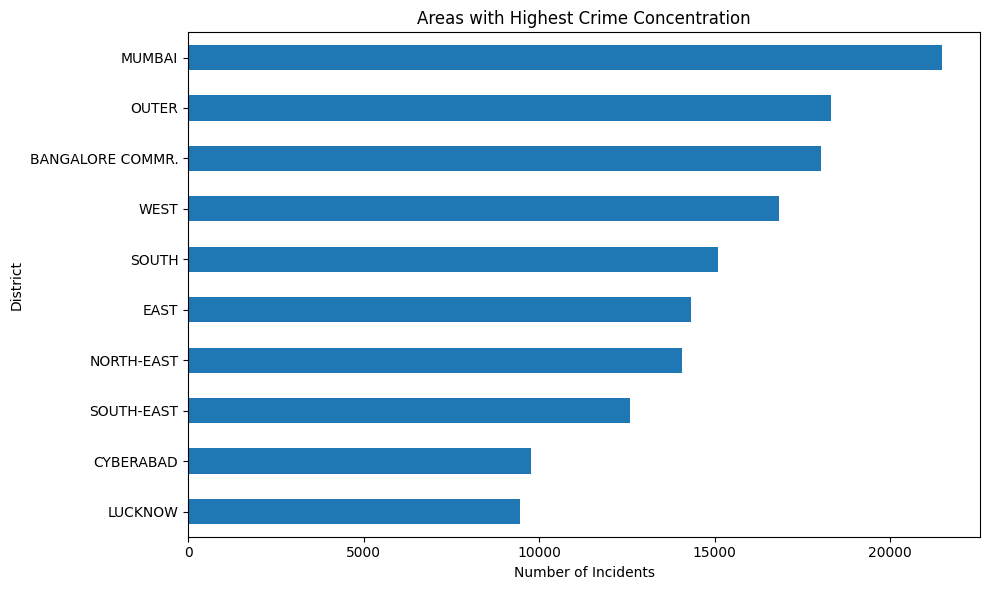

DISTRICT
MUMBAI              21489
OUTER               18322
BANGALORE COMMR.    18023
WEST                16845
SOUTH               15085
EAST                14336
NORTH-EAST          14076
SOUTH-EAST          12594
CYBERABAD            9759
LUCKNOW              9450
Name: count, dtype: int64


In [ ]:
area_crime = df["DISTRICT"].value_counts().head(10)

plt.figure(figsize=(10, 6))
area_crime.sort_values().plot(kind="barh")

plt.title("Areas with Highest Crime Concentration")
plt.xlabel("Number of Incidents")
plt.ylabel("District")

plt.tight_layout()
plt.show()

print(area_crime)

### Observation

The crime incidents are not evenly distributed across all districts. Some major districts and urban areas show significantly higher crime concentration than others.

### Interpretation

This suggests that geographical location plays an important role in crime occurrence. Urban regions may have higher crime reporting due to population density, economic activity, and administrative coverage.

### Conclusion

District and location-related features should be considered important for future predictive models.

### 2.2 Crime Hotspot Regions

This scatter plot visualizes crime incidents using latitude and longitude values.

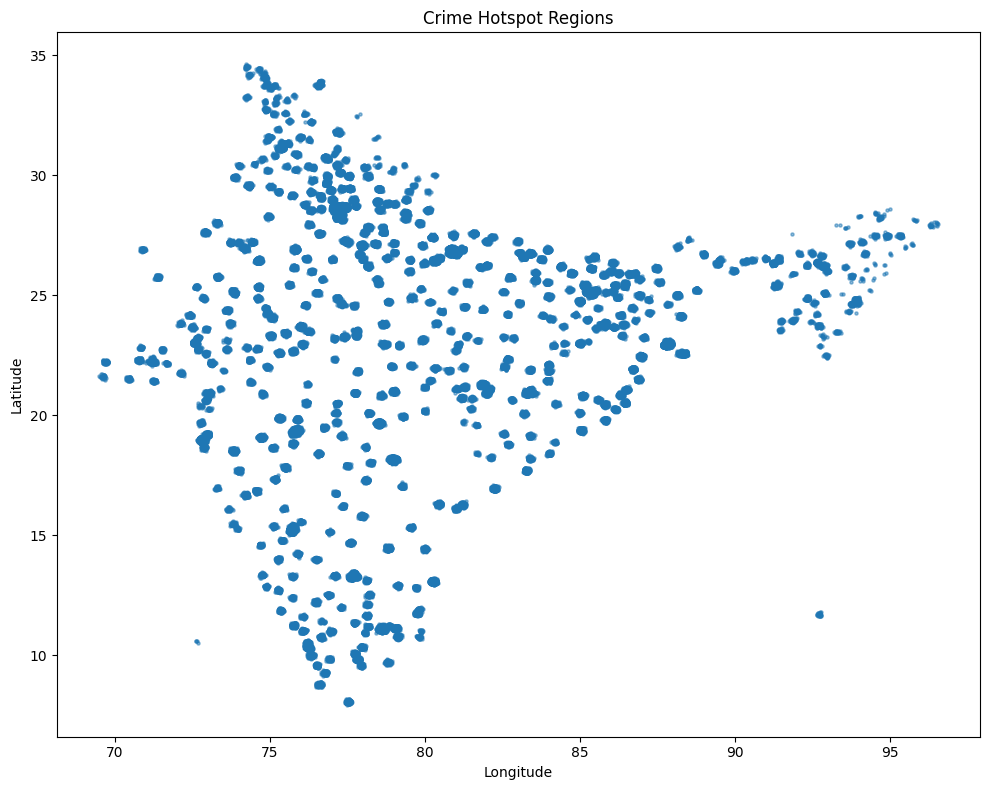

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df["LONGITUDE"],
    df["LATITUDE"],
    alpha=0.5,
    s=5
)

plt.title("Crime Hotspot Regions")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

### Observation

Crime incidents appear geographically clustered rather than evenly distributed across all coordinates.

### Interpretation

The clustering pattern indicates the presence of potential hotspot regions where crime incidents are more concentrated.

### Conclusion

Latitude, longitude, district, and state information are important spatial features for hotspot identification and predictive policing.

## 3. Crime-Type Analysis

Crime-type analysis helps identify the most frequent crime categories and understand how different crime types vary over time.


### 3.1 Top 10 Crime Categories

This analysis identifies the most common crime categories in the dataset.

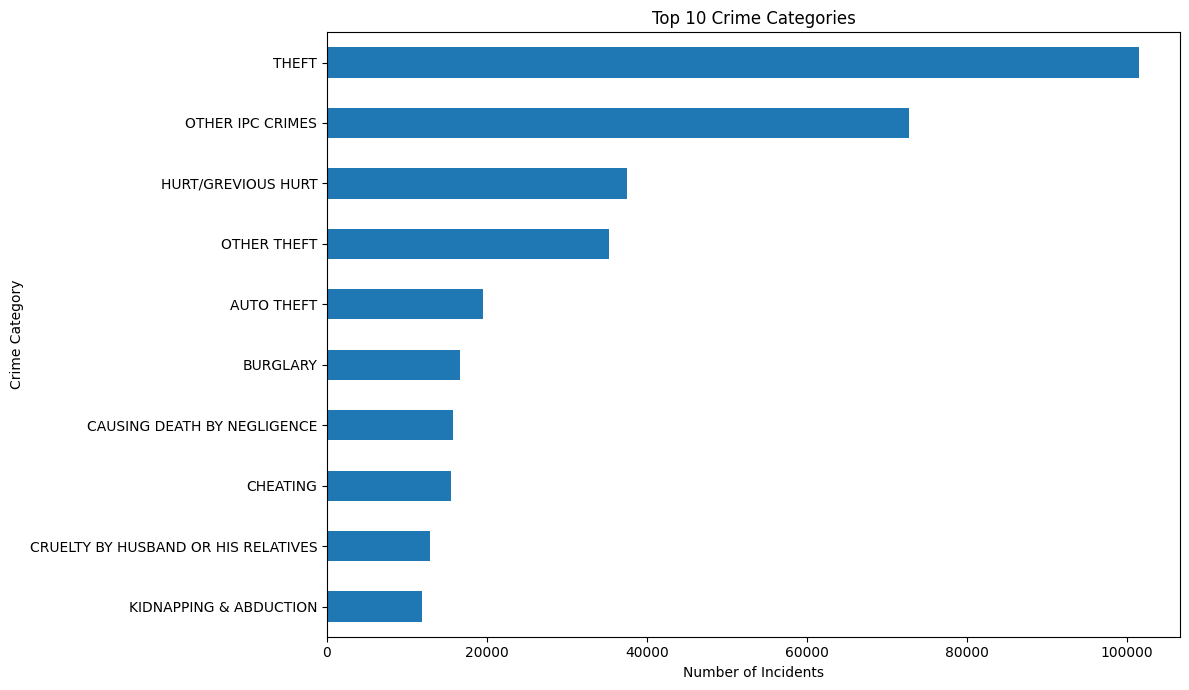

CRIME_CATEGORY
THEFT                                  101557
OTHER IPC CRIMES                        72737
HURT/GREVIOUS HURT                      37522
OTHER THEFT                             35290
AUTO THEFT                              19572
BURGLARY                                16649
CAUSING DEATH BY NEGLIGENCE             15798
CHEATING                                15530
CRUELTY BY HUSBAND OR HIS RELATIVES     12878
KIDNAPPING & ABDUCTION                  11912
Name: count, dtype: int64


In [ ]:
top_crimes = df["CRIME_CATEGORY"].value_counts().head(10)

plt.figure(figsize=(12, 7))
top_crimes.sort_values().plot(kind="barh")

plt.title("Top 10 Crime Categories")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Category")

plt.tight_layout()
plt.show()

print(top_crimes)

### Observation

The dataset is dominated by a few crime categories. Theft-related crimes and other IPC crimes appear among the most frequent categories.

### Interpretation

The distribution of crime categories is imbalanced, meaning some crime types occur much more frequently than others.

### Conclusion

Crime category imbalance should be considered during machine learning model development and evaluation.


### 3.2 Crime Trends Over Time

This analysis examines how major crime categories vary across different years.

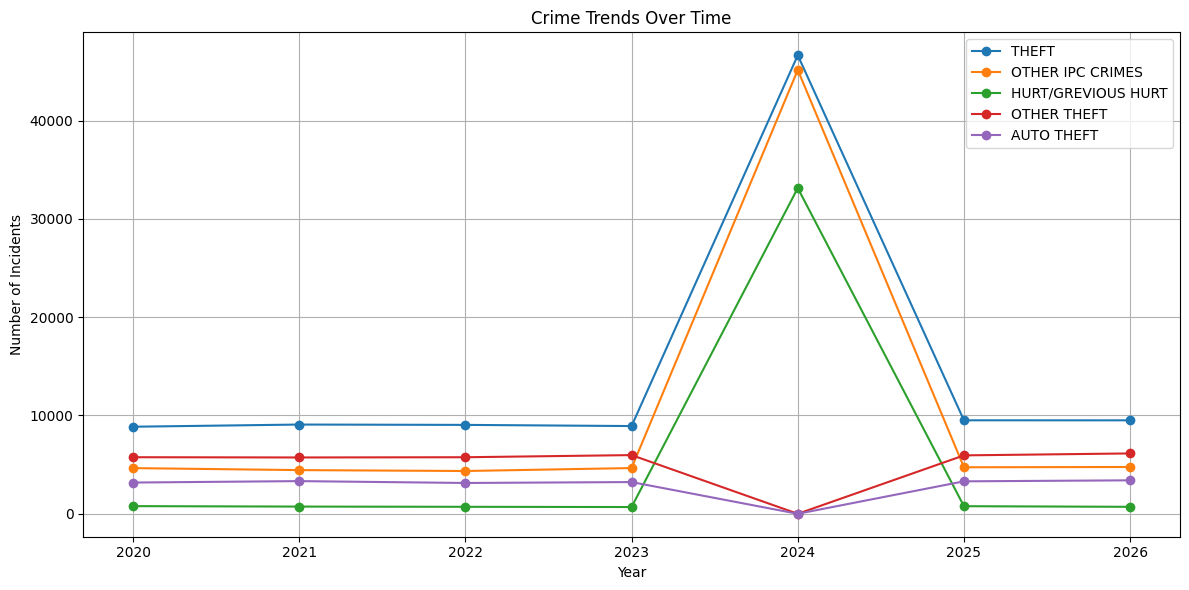

In [ ]:
df["YEAR"] = df["TIMESTAMP"].dt.year

crime_trend = (
    df.groupby(["YEAR", "CRIME_CATEGORY"])
      .size()
      .unstack(fill_value=0)
)

top_crimes = df["CRIME_CATEGORY"].value_counts().head(5).index

plt.figure(figsize=(12, 6))

for crime in top_crimes:
    plt.plot(
        crime_trend.index,
        crime_trend[crime],
        marker="o",
        label=crime
    )

plt.title("Crime Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

Major crime categories remain consistently present across the years. Some unusual spikes may be visible in specific years.

### Interpretation

The trend analysis indicates that crime patterns vary over time. However, sudden spikes should be carefully verified because they may occur due to reporting changes, data collection differences, or dataset inconsistencies.

### Conclusion

Historical crime trends provide useful information, but anomalies should be verified before using them for final model training.

## 4. Correlation Analysis

Correlation analysis helps examine relationships among numerical demographic and socio-economic features.

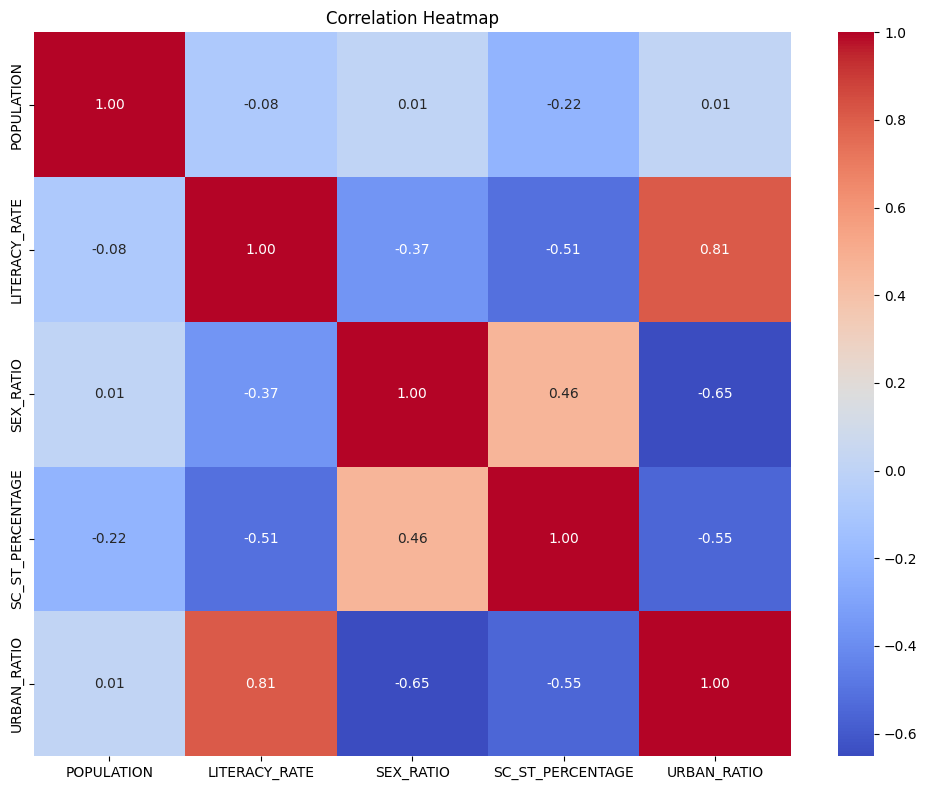

                  POPULATION  LITERACY_RATE  SEX_RATIO  SC_ST_PERCENTAGE  \
POPULATION          1.000000      -0.080651   0.011301         -0.217717   
LITERACY_RATE      -0.080651       1.000000  -0.365364         -0.512008   
SEX_RATIO           0.011301      -0.365364   1.000000          0.461918   
SC_ST_PERCENTAGE   -0.217717      -0.512008   0.461918          1.000000   
URBAN_RATIO         0.013586       0.807583  -0.651929         -0.552291   

                  URBAN_RATIO  
POPULATION           0.013586  
LITERACY_RATE        0.807583  
SEX_RATIO           -0.651929  
SC_ST_PERCENTAGE    -0.552291  
URBAN_RATIO          1.000000  


In [ ]:
numeric_cols = [
    "POPULATION",
    "LITERACY_RATE",
    "SEX_RATIO",
    "SC_ST_PERCENTAGE",
    "URBAN_RATIO"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

print(corr_matrix)

### Observation

The correlation heatmap shows relationships among numerical variables such as population, literacy rate, sex ratio, SC/ST percentage, and urban ratio.

### Interpretation

Some demographic variables show meaningful relationships with each other. For example, urban ratio may be associated with literacy rate and other socio-economic indicators.

### Conclusion

Demographic and socio-economic variables can provide useful contextual information for feature selection and future predictive modeling.

## 5. Key Insights

- Crime frequency varies across different hours of the day.
- Weekday and weekend crime distribution appears relatively consistent when adjusted for the number of days.
- Monthly crime trends suggest seasonal variation, with higher incidents during January, February, November, and December.
- Crime incidents are concentrated in specific districts and urban regions.
- Spatial clustering suggests the presence of potential hotspot regions.
- Crime categories are imbalanced, with some categories occurring much more frequently than others.
- Correlation analysis shows relationships among demographic and socio-economic variables.

## 6. Conclusion

The EDA reveals important temporal, spatial, crime-type, and demographic patterns in the dataset. Hour, month, district, latitude, longitude, population, literacy rate, and urban ratio appear useful for further analysis and future machine learning models. The results also show that crime category imbalance is an important challenge that must be handled during model training and evaluation.